# 什么是相机标定，为什么要进行相机标定

> **作者：** Humbunklung  
> **日期：** 2026-07-23  
> **关键词：** 计算机视觉、相机标定、张正友标定法、比例因子、OpenCV

---

## 目录

1. [相机标定的定义](#1-相机标定的定义)
2. [为什么要进行相机标定](#2-为什么要进行相机标定)
3. [针孔相机模型与坐标系](#3-针孔相机模型与坐标系)
4. [张正友相机标定法](#4-张正友相机标定法)
5. [比例因子计算方法](#5-比例因子计算方法)
6. [两种方法的对比总结](#6-两种方法的对比总结)
7. [参考文献](#7-参考文献)

---

## 1. 相机标定的定义

**相机标定（Camera Calibration）** 是指通过一系列数学方法，估计相机成像模型中各项参数的过程。这些参数包括描述相机内部光学和几何特性的**内参（Intrinsic Parameters）**，以及描述相机在三维世界中位置和姿态的**外参（Extrinsic Parameters）**，以及描述镜头几何失真的**畸变系数（Distortion Coefficients）**。

通俗地说，相机标定就是为相机建立一套精确的数学模型，使得计算机能够通过这个模型，将二维图像中的像素坐标与三维世界中的物理坐标相互转换。

| 参数类型 | 具体内容 | 作用 |
|:---:|:---:|:---|
| **内参矩阵 K** | 焦距 $f_x, f_y$，主点坐标 $c_x, c_y$ | 描述相机将3D点投影到图像平面的方式 |
| **外参 [R \| t]** | 旋转矩阵 R，平移向量 t | 描述相机坐标系相对于世界坐标系的位姿 |
| **畸变系数** | 径向 $k_1, k_2, k_3$，切向 $p_1, p_2$ | 描述镜头引入的几何失真 |

---

## 2. 为什么要进行相机标定

在计算机视觉的实际应用中，相机标定是几乎所有三维感知任务的先决条件，其重要性体现在以下三个层面。

**第一，建立坐标映射关系。** 相机成像是一个将三维世界降维投影到二维图像的过程，这一过程中深度信息被丢失。通过标定获得的内外参数，我们可以建立像素坐标与世界坐标之间的精确数学关系，这是三维重建、机器人定位、自动驾驶感知等任务的基础。

**第二，校正镜头畸变。** 实际相机镜头并非理想的针孔模型，透镜的形状和组装误差会引入径向畸变（桶形畸变或枕形畸变）和切向畸变。这些畸变会使图像中的直线变弯，严重影响几何测量精度。标定可以求出畸变系数，进而对图像进行去畸变处理。

**第三，提高系统测量精度。** 在工业视觉检测、医学图像分析、精密测量等高要求场景中，未经标定的相机会引入系统性误差。精确的标定是保证测量结果可靠性的必要前提。

---

## 3. 针孔相机模型与坐标系

理解相机标定，首先需要了解相机的数学模型。最常用的是**针孔相机模型（Pinhole Camera Model）**，它将相机简化为一个光线通过单个点（光心）投射到成像平面的理想模型。

### 3.1 四个坐标系

相机成像过程涉及四个坐标系之间的连续变换：

$$\text{世界坐标系} \xrightarrow{[R|t]} \text{相机坐标系} \xrightarrow{\text{透视投影}} \text{图像物理坐标系} \xrightarrow{\text{缩放平移}} \text{像素坐标系}$$

下图展示了这四个坐标系的关系：

In [1]:
# ── 环境准备 ──────────────────────────────────────────────────────────────
import cv2
import numpy as np
# import matplotlib
import platform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# from matplotlib import font_manager
# import warnings
# warnings.filterwarnings('ignore')

# # 配置中文字体（使用系统内置的 Noto CJK 字体）
# _FONT_PATH = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
# try:
#     _zh_font = font_manager.FontProperties(fname=_FONT_PATH)
#     _zh_font_sm = font_manager.FontProperties(fname=_FONT_PATH, size=9)
#     _zh_font_md = font_manager.FontProperties(fname=_FONT_PATH, size=10)
#     _zh_font_lg = font_manager.FontProperties(fname=_FONT_PATH, size=13)
#     _zh_font_xl = font_manager.FontProperties(fname=_FONT_PATH, size=14)
#     print("✓ 中文字体加载成功")
# except Exception:
#     _zh_font = _zh_font_sm = _zh_font_md = _zh_font_lg = _zh_font_xl = None
#     print("⚠ 未找到 Noto CJK 字体，中文标注可能显示为方框")

if platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False

print(f"OpenCV 版本: {cv2.__version__}")
print(f"NumPy  版本: {np.__version__}")

OpenCV 版本: 5.0.0
NumPy  版本: 2.5.1


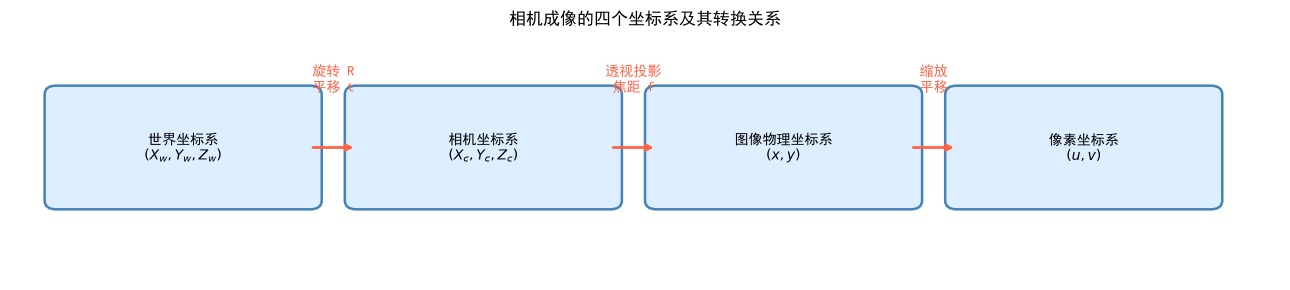

In [2]:
# ── 图1：四个坐标系关系示意图 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis('off')
ax.set_xlim(0, 11)
ax.set_ylim(0, 2.8)

boxes = [
    ('世界坐标系\n$(X_w, Y_w, Z_w)$', 0.4),
    ('相机坐标系\n$(X_c, Y_c, Z_c)$', 3.0),
    ('图像物理坐标系\n$(x, y)$', 5.6),
    ('像素坐标系\n$(u, v)$', 8.2),
]
arrows = ['旋转 R\n平移 t', '透视投影\n焦距 f', '缩放\n平移']

for (label, x) in boxes:
    rect = mpatches.FancyBboxPatch((x, 0.9), 2.2, 1.2,
                                    boxstyle='round,pad=0.1',
                                    linewidth=1.8, edgecolor='steelblue',
                                    facecolor='#ddeeff')
    ax.add_patch(rect)
    # ax.text(x + 1.1, 1.5, label, ha='center', va='center',
    #         fontproperties=_zh_font_sm)
    ax.text(x + 1.1, 1.5, label, ha='center', va='center')
for arrow_label, x_start in zip(arrows, [2.6, 5.2, 7.8]):
    ax.annotate('', xy=(x_start + 0.4, 1.5), xytext=(x_start, 1.5),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
    # ax.text(x_start + 0.2, 2.1, arrow_label, ha='center', va='bottom',
    #         fontproperties=_zh_font_sm, color='tomato')
    ax.text(x_start + 0.2, 2.1, arrow_label, ha='center', va='bottom', color='tomato')

# ax.set_title('相机成像的四个坐标系及其转换关系', fontproperties=_zh_font_xl)
ax.set_title('相机成像的四个坐标系及其转换关系')
plt.tight_layout()
plt.show()

### 3.2 针孔相机模型的数学描述

完整的相机投影模型可以用以下矩阵方程表示：

$$Z \begin{pmatrix} u \\ v \\ 1 \end{pmatrix} = \underbrace{\begin{pmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{pmatrix}}_{\text{内参矩阵 } K} \underbrace{\begin{pmatrix} R & t \end{pmatrix}}_{\text{外参}} \begin{pmatrix} X_w \\ Y_w \\ Z_w \\ 1 \end{pmatrix}$$

其中，$f_x = f / d_x$，$f_y = f / d_y$ 分别是以像素为单位的水平和垂直焦距，$c_x, c_y$ 是主点（光轴与成像平面的交点）的像素坐标，$Z$ 是尺度因子（即物点的深度）。

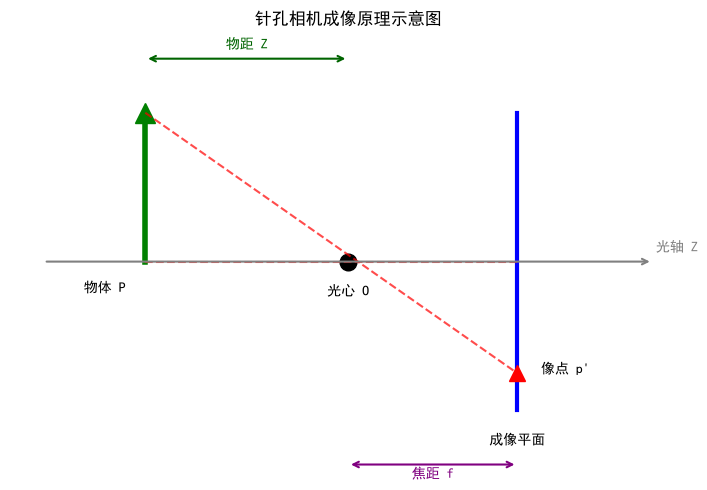

In [3]:
# ── 图2：针孔相机成像原理示意图 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 10)
ax.set_ylim(-3.2, 3.2)
ax.set_aspect('equal')
ax.axis('off')

# 光轴
ax.annotate('', xy=(9.5, 0), xytext=(0.5, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
# ax.text(9.55, 0.15, '光轴 Z', fontsize=10, color='gray', fontproperties=_zh_font_md)
ax.text(9.55, 0.15, '光轴 Z', fontsize=10, color='gray')

# 物体
ax.plot([2, 2], [0, 2.2], 'g-', lw=4)
ax.plot([2], [2.2], 'g^', markersize=14)
# ax.text(1.4, -0.45, '物体 P', fontsize=10, ha='center', fontproperties=_zh_font_md)
ax.text(1.4, -0.45, '物体 P', fontsize=10, ha='center')

# 光心
ax.plot(5, 0, 'ko', markersize=12)
# ax.text(5, -0.5, '光心 O', fontsize=10, ha='center', fontproperties=_zh_font_md)
ax.text(5, -0.5, '光心 O', fontsize=10, ha='center')

# 成像平面
ax.plot([7.5, 7.5], [-2.2, 2.2], 'b-', lw=3)
# ax.text(7.5, -2.7, '成像平面', fontsize=10, ha='center', fontproperties=_zh_font_md)
ax.text(7.5, -2.7, '成像平面', fontsize=10, ha='center')

# 投影线
ax.plot([2, 7.5], [2.2, -1.65], 'r--', lw=1.5, alpha=0.7)
ax.plot([2, 7.5], [0, 0], 'r--', lw=1.5, alpha=0.7)

# 像点
ax.plot([7.5], [-1.65], 'r^', markersize=12)
# ax.text(7.85, -1.65, "像点 p'", fontsize=10, fontproperties=_zh_font_md)
ax.text(7.85, -1.65, "像点 p'", fontsize=10)

# 焦距标注
ax.annotate('', xy=(7.5, -3.0), xytext=(5, -3.0),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
# ax.text(6.25, -3.2, '焦距 f', fontsize=10, ha='center', color='purple', fontproperties=_zh_font_md)
ax.text(6.25, -3.2, '焦距 f', fontsize=10, ha='center', color='purple')

# 物距标注
ax.annotate('', xy=(5, 3.0), xytext=(2, 3.0),
            arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.5))
# ax.text(3.5, 3.15, '物距 Z', fontsize=10, ha='center', color='darkgreen', fontproperties=_zh_font_md)
ax.text(3.5, 3.15, '物距 Z', fontsize=10, ha='center', color='darkgreen')

# ax.set_title('针孔相机成像原理示意图', fontproperties=_zh_font_xl, pad=15)
ax.set_title('针孔相机成像原理示意图', pad=15)
plt.tight_layout()
plt.show()

### 3.3 镜头畸变模型

实际相机镜头会引入畸变，主要分为两类：

**径向畸变（Radial Distortion）** 由透镜形状引起，表现为图像向中心收缩（桶形）或向外扩张（枕形）：

$$\hat{x} = x(1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$
$$\hat{y} = y(1 + k_1 r^2 + k_2 r^4 + k_3 r^6)$$

**切向畸变（Tangential Distortion）** 由透镜与成像平面不平行引起：

$$\hat{x} = x + [2p_1 y + p_2(r^2 + 2x^2)]$$
$$\hat{y} = y + [p_1(r^2 + 2y^2) + 2p_2 x]$$

其中 $(x, y)$ 为理想归一化图像坐标，$(\hat{x}, \hat{y})$ 为畸变后的坐标，$r^2 = x^2 + y^2$。

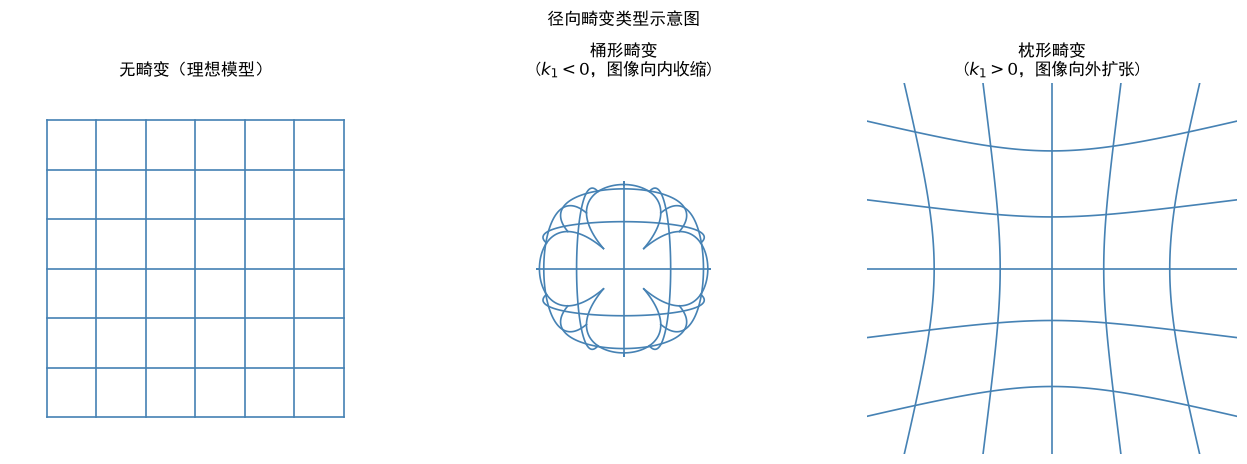

In [4]:
# ── 图3：径向畸变类型对比 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

def draw_distorted_grid(ax, distort_fn, title):
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    # ax.set_title(title, fontproperties=_zh_font_lg)
    ax.set_title(title)
    for v in np.linspace(-1.2, 1.2, 7):
        pts = [distort_fn(u, v) for u in np.linspace(-1.2, 1.2, 120)]
        ax.plot([p[0] for p in pts], [p[1] for p in pts], 'steelblue', lw=1.2)
    for u in np.linspace(-1.2, 1.2, 7):
        pts = [distort_fn(u, v) for v in np.linspace(-1.2, 1.2, 120)]
        ax.plot([p[0] for p in pts], [p[1] for p in pts], 'steelblue', lw=1.2)

draw_distorted_grid(axes[0], lambda x, y: (x, y), '无畸变（理想模型）')
draw_distorted_grid(axes[1],
    lambda x, y: (x*(1 - 0.3*(x**2+y**2)), y*(1 - 0.3*(x**2+y**2))),
    '桶形畸变\n($k_1 < 0$，图像向内收缩)')
draw_distorted_grid(axes[2],
    lambda x, y: (x*(1 + 0.3*(x**2+y**2)), y*(1 + 0.3*(x**2+y**2))),
    '枕形畸变\n($k_1 > 0$，图像向外扩张)')

# plt.suptitle('径向畸变类型示意图', fontproperties=_zh_font_xl, y=1.02)
plt.suptitle('径向畸变类型示意图', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. 张正友相机标定法

### 4.1 方法简介

**张正友标定法（Zhang's Method）** 由微软研究院张正友博士于1998年提出，发表于 IEEE Transactions on Pattern Analysis and Machine Intelligence。该方法介于传统需要高精度三维标定物的方法和完全自标定方法之间，仅需使用一个打印的**二维棋盘格标定板**，从多个角度拍摄若干张图像即可完成标定，兼具精度高、操作简便的优点，已被 OpenCV 等主流视觉库直接集成。

### 4.2 核心原理

张正友标定法将世界坐标系固定于棋盘格平面上，令所有角点的 $Z_w = 0$。此时，三维到二维的投影关系退化为平面单应性（Homography）：

$$Z \begin{pmatrix} u \\ v \\ 1 \end{pmatrix} = K \begin{pmatrix} r_1 & r_2 & t \end{pmatrix} \begin{pmatrix} X_w \\ Y_w \\ 1 \end{pmatrix} = H \begin{pmatrix} X_w \\ Y_w \\ 1 \end{pmatrix}$$

其中 $H = K[r_1, r_2, t]$ 是一个 $3\times3$ 的单应性矩阵，可由每张图像的角点对应关系求解。利用旋转矩阵列向量之间的单位正交约束 $r_1^T r_1 = r_2^T r_2 = 1$，$r_1^T r_2 = 0$，可以建立关于内参矩阵的线性方程组，从而在不需要三维标定物的情况下恢复内参。

### 4.3 标定流程

下图展示了使用 OpenCV 实现张正友标定法的完整步骤：

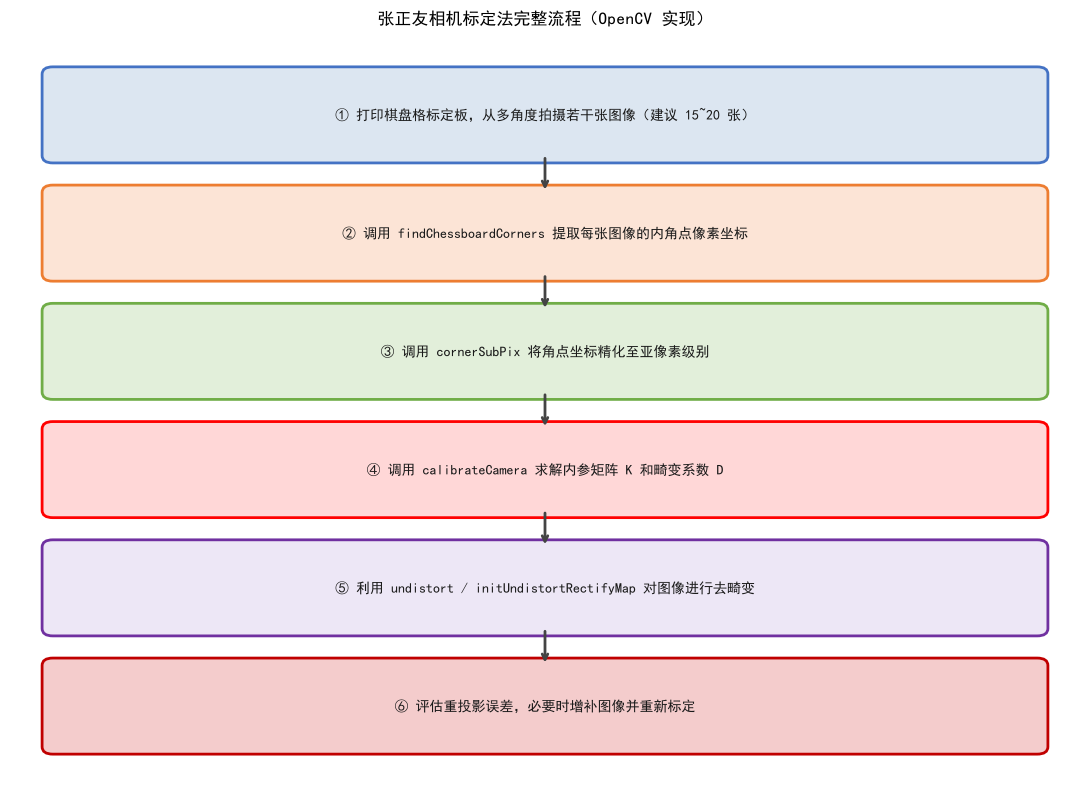

In [5]:
# ── 图4：张正友标定法完整流程图 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

steps = [
    ('① 打印棋盘格标定板，从多角度拍摄若干张图像（建议 15~20 张）', '#4472C4', '#dce6f1'),
    ('② 调用 findChessboardCorners 提取每张图像的内角点像素坐标', '#ED7D31', '#fce4d6'),
    ('③ 调用 cornerSubPix 将角点坐标精化至亚像素级别', '#70AD47', '#e2efda'),
    ('④ 调用 calibrateCamera 求解内参矩阵 K 和畸变系数 D', '#FF0000', '#ffd7d7'),
    ('⑤ 利用 undistort / initUndistortRectifyMap 对图像进行去畸变', '#7030A0', '#ede7f6'),
    ('⑥ 评估重投影误差，必要时增补图像并重新标定', '#C00000', '#f4cccc'),
]

y_positions = [9.0, 7.4, 5.8, 4.2, 2.6, 1.0]

for (text, edge_color, face_color), y in zip(steps, y_positions):
    rect = mpatches.FancyBboxPatch((0.4, y - 0.55), 9.2, 1.1,
                                    boxstyle='round,pad=0.1',
                                    linewidth=2, edgecolor=edge_color,
                                    facecolor=face_color)
    ax.add_patch(rect)
    # ax.text(5, y, text, ha='center', va='center',
    #         fontproperties=_zh_font_md, color='#1a1a1a')
    ax.text(5, y, text, ha='center', va='center', color='#1a1a1a')

for y_cur, y_next in zip(y_positions[:-1], y_positions[1:]):
    ax.annotate('', xy=(5, y_next + 0.55), xytext=(5, y_cur - 0.55),
                arrowprops=dict(arrowstyle='->', color='#444444', lw=2))

# ax.set_title('张正友相机标定法完整流程（OpenCV 实现）',
#              fontproperties=_zh_font_xl, pad=12)
ax.set_title('张正友相机标定法完整流程（OpenCV 实现）', pad=12)
plt.tight_layout()
plt.show()

### 4.4 OpenCV 代码实现

以下代码完整演示了张正友标定法的实现过程，包括：生成模拟棋盘格图像、角点检测与精化、执行标定、去畸变处理，以及重投影误差评估。

In [6]:
# ── 步骤 1：生成模拟棋盘格图像（实际应用中应替换为真实拍摄的照片）─────────

CHECKERBOARD = (6, 9)   # 棋盘格内角点数量 (行数, 列数)
SQUARE_SIZE  = 0.025    # 每个方格的物理边长（单位：米）

def generate_checkerboard(rows, cols, step=56, margin=60,
                           img_h=480, img_w=640):
    """生成标准棋盘格灰度图像。"""
    img = np.ones((img_h, img_w), dtype=np.uint8) * 255
    for i in range(cols + 1):
        for j in range(rows + 1):
            if (i + j) % 2 == 0:
                x1 = margin + i * step
                y1 = margin + j * step
                x2 = min(x1 + step, img_w - 1)
                y2 = min(y1 + step, img_h - 1)
                cv2.rectangle(img, (x1, y1), (x2, y2), 0, -1)
    return img

# 生成一张基准棋盘格图像
base_board = generate_checkerboard(*CHECKERBOARD)

# 通过仿射变换模拟多角度拍摄，生成 12 张不同视角的图像
def make_perspective_views(base, n=12):
    h, w = base.shape
    views = []
    np.random.seed(42)
    for _ in range(n):
        # 随机仿射变换（模拟轻微旋转和缩放）
        angle = np.random.uniform(-12, 12)
        scale = np.random.uniform(0.85, 1.0)
        M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, scale)
        M[0, 2] += np.random.uniform(-20, 20)
        M[1, 2] += np.random.uniform(-15, 15)
        warped = cv2.warpAffine(base, M, (w, h),
                                flags=cv2.INTER_LINEAR,
                                borderMode=cv2.BORDER_CONSTANT,
                                borderValue=255)
        views.append(warped)
    return views

images = make_perspective_views(base_board, n=12)
print(f"共生成 {len(images)} 张模拟标定图像，尺寸：{images[0].shape}")

共生成 12 张模拟标定图像，尺寸：(480, 640)


成功检测到角点的图像数量：12 / 12


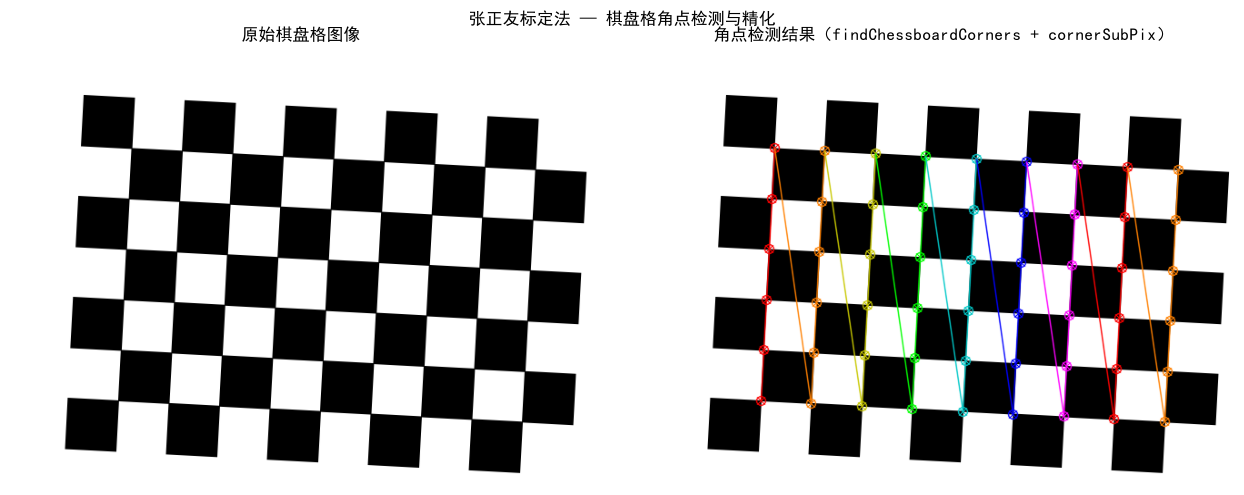

In [7]:
# ── 步骤 2：角点检测与亚像素精化 ──────────────────────────────────────────

# 停止准则：最大迭代次数 30 次，或精度达到 0.001 像素
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# 准备世界坐标系中的角点坐标（Z=0 平面）
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0],
                        0:CHECKERBOARD[1]].T.reshape(-1, 2) * SQUARE_SIZE

objpoints = []  # 3D 世界坐标点列表
imgpoints = []  # 2D 图像像素坐标点列表
valid_images = []

for idx, gray in enumerate(images):
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
    if ret:
        # cornerSubPix：将角点精化到亚像素精度
        corners_refined = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp)
        imgpoints.append(corners_refined)
        valid_images.append(gray)

print(f"成功检测到角点的图像数量：{len(valid_images)} / {len(images)}")

# 可视化第一张有效图像的角点检测结果
img_vis = cv2.cvtColor(valid_images[0], cv2.COLOR_GRAY2BGR)
cv2.drawChessboardCorners(img_vis, CHECKERBOARD, imgpoints[0], True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(valid_images[0], cmap='gray')
# axes[0].set_title('原始棋盘格图像', fontproperties=_zh_font_lg)
axes[0].set_title('原始棋盘格图像')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
# axes[1].set_title('角点检测结果（findChessboardCorners + cornerSubPix）',
#                    fontproperties=_zh_font_lg)
axes[1].set_title('角点检测结果（findChessboardCorners + cornerSubPix）')
axes[1].axis('off')
# plt.suptitle('张正友标定法 — 棋盘格角点检测与精化', fontproperties=_zh_font_xl)
plt.suptitle('张正友标定法 — 棋盘格角点检测与精化')
plt.tight_layout()
plt.show()

In [8]:
# ── 步骤 3：执行相机标定 ───────────────────────────────────────────────────

img_size = (valid_images[0].shape[1], valid_images[0].shape[0])  # (width, height)

# cv2.calibrateCamera 返回：
#   ret    — 平均重投影误差（越小越好，通常要求 < 1.0 像素）
#   mtx    — 3×3 相机内参矩阵 K
#   dist   — 畸变系数向量 [k1, k2, p1, p2, k3]
#   rvecs  — 每张图像的旋转向量列表
#   tvecs  — 每张图像的平移向量列表
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, img_size, None, None)

print("=" * 55)
print("  相机标定结果")
print("=" * 55)
print(f"\n平均重投影误差 (RMS): {ret:.4f} 像素")
print("\n内参矩阵 K:")
print(f"  fx = {mtx[0,0]:.2f} px,  fy = {mtx[1,1]:.2f} px")
print(f"  cx = {mtx[0,2]:.2f} px,  cy = {mtx[1,2]:.2f} px")
print("\n  K =\n", np.round(mtx, 2))
print("\n畸变系数 [k1, k2, p1, p2, k3]:")
print("  ", np.round(dist.ravel(), 6))
print("=" * 55)

  相机标定结果

平均重投影误差 (RMS): 0.0637 像素

内参矩阵 K:
  fx = 156005.03 px,  fy = 156305.83 px
  cx = 333.07 px,  cy = 655.47 px

  K =
 [[1.5600503e+05 0.0000000e+00 3.3307000e+02]
 [0.0000000e+00 1.5630583e+05 6.5547000e+02]
 [0.0000000e+00 0.0000000e+00 1.0000000e+00]]

畸变系数 [k1, k2, p1, p2, k3]:
   [-4.505586 -2.842325 -0.021303 -0.007666 -0.      ]


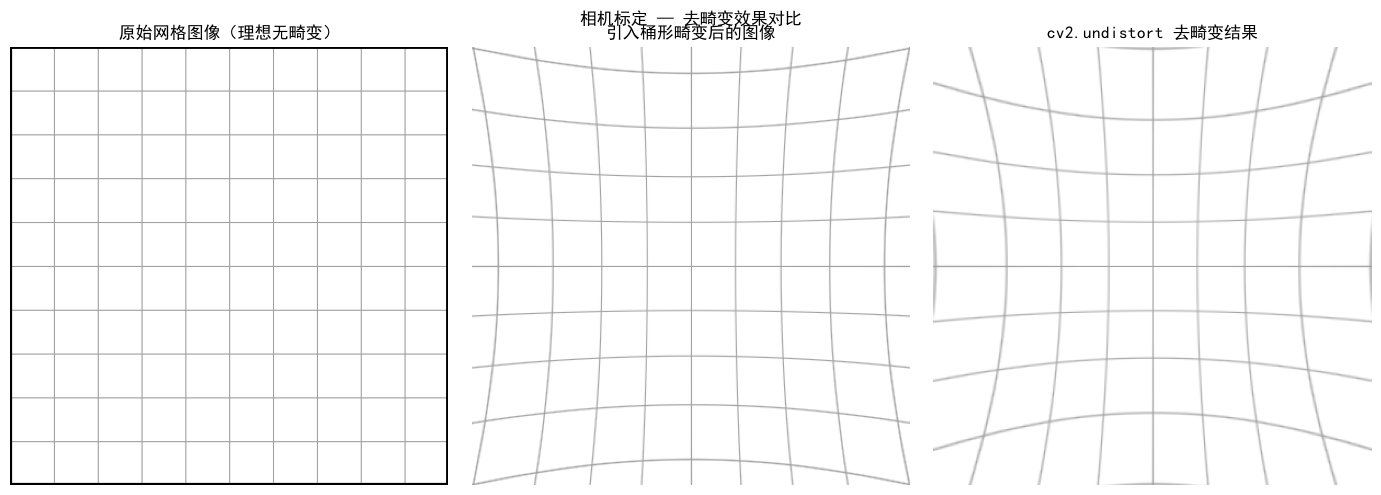

In [9]:
# ── 步骤 4：去畸变处理 ────────────────────────────────────────────────────
# 模拟一张带有桶形畸变的网格图像，演示去畸变效果

h_g, w_g = 400, 400
img_grid = np.ones((h_g, w_g, 3), dtype=np.uint8) * 255
for i in range(0, h_g, 40):
    cv2.line(img_grid, (0, i), (w_g, i), (160, 160, 160), 1)
for j in range(0, w_g, 40):
    cv2.line(img_grid, (j, 0), (j, h_g), (160, 160, 160), 1)
cv2.rectangle(img_grid, (0, 0), (w_g-1, h_g-1), (0, 0, 0), 2)

# 使用模拟的相机参数和畸变系数引入桶形畸变
K_sim = np.array([[350., 0., 200.], [0., 350., 200.], [0., 0., 1.]])
D_sim = np.array([-0.4, 0.15, 0., 0., 0.])
map1, map2 = cv2.initUndistortRectifyMap(
    K_sim, D_sim, None, K_sim, (w_g, h_g), cv2.CV_32FC1)
img_distorted = cv2.remap(img_grid, map1, map2, cv2.INTER_LINEAR)

# 使用 cv2.undistort 进行去畸变
img_undistorted = cv2.undistort(img_distorted, K_sim, D_sim)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_grid)
# axes[0].set_title('原始网格图像（理想无畸变）', fontproperties=_zh_font_lg)
axes[0].set_title('原始网格图像（理想无畸变）')
axes[0].axis('off')
axes[1].imshow(img_distorted)
# axes[1].set_title('引入桶形畸变后的图像', fontproperties=_zh_font_lg)
axes[1].set_title('引入桶形畸变后的图像')
axes[1].axis('off')
axes[2].imshow(img_undistorted)
# axes[2].set_title('cv2.undistort 去畸变结果', fontproperties=_zh_font_lg)
axes[2].set_title('cv2.undistort 去畸变结果')
axes[2].axis('off')
# plt.suptitle('相机标定 — 去畸变效果对比', fontproperties=_zh_font_xl)
plt.suptitle('相机标定 — 去畸变效果对比')
plt.tight_layout()
plt.show()

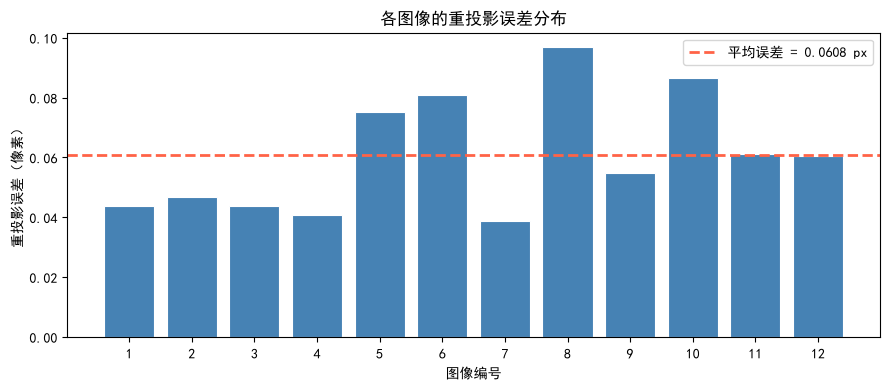

平均重投影误差：0.0608 像素
（通常认为误差 < 1.0 像素为合格，< 0.5 像素为优秀）


In [10]:
# ── 步骤 5：重投影误差评估 ────────────────────────────────────────────────
# 重投影误差是衡量标定质量的核心指标：
# 将已知3D点用标定结果重新投影到图像，计算与实际检测点的距离误差

errors = []
for i in range(len(objpoints)):
    # 将3D点重新投影到图像平面
    projected, _ = cv2.projectPoints(
        objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    # 计算与实际检测角点的欧氏距离
    actual = imgpoints[i].reshape(-1, 2).astype(np.float32)
    proj   = projected.reshape(-1, 2).astype(np.float32)
    err = np.sqrt(np.mean(np.sum((actual - proj)**2, axis=1)))
    errors.append(err)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(range(1, len(errors)+1), errors,
              color='steelblue', edgecolor='white', linewidth=0.8)
ax.axhline(np.mean(errors), color='tomato', lw=2, ls='--',
           label=f'平均误差 = {np.mean(errors):.4f} px')
# ax.set_xlabel('图像编号', fontproperties=_zh_font_md)
ax.set_xlabel('图像编号')
# ax.set_ylabel('重投影误差（像素）', fontproperties=_zh_font_md)
ax.set_ylabel('重投影误差（像素）')
# ax.set_title('各图像的重投影误差分布', fontproperties=_zh_font_xl)
ax.set_title('各图像的重投影误差分布')
# ax.legend(prop=_zh_font_md)
ax.legend()
ax.set_xticks(range(1, len(errors)+1))
plt.tight_layout()
plt.show()

print(f"平均重投影误差：{np.mean(errors):.4f} 像素")
print("（通常认为误差 < 1.0 像素为合格，< 0.5 像素为优秀）")

---

## 5. 比例因子计算方法

### 5.1 方法简介

**比例因子计算方法（Scale Factor / Pixels-Per-Metric Method）** 是一种简化的相机测量方法。在某些不需要完整三维标定的应用场景中，如果被测物体与相机之间的距离固定，且所有物体处于同一深度平面，可以通过在场景中放置一个**已知物理尺寸的参考物**，计算像素与物理单位之间的换算比例，从而估算其他物体的实际尺寸。

$$\text{比例因子} = \frac{\text{参考物的像素宽度（px）}}{\text{参考物的实际宽度（cm）}}$$

$$\text{待测物实际宽度} = \frac{\text{待测物的像素宽度}}{\text{比例因子}}$$

### 5.2 方法局限性

比例因子方法成立的前提条件较为严格，实际使用时需注意以下限制：

| 假设条件 | 说明 |
|:---|:---|
| **同一深度平面** | 参考物与待测物必须在同一距离处，否则透视效应会引入误差 |
| **畸变较小** | 图像边缘的畸变会导致比例因子在不同区域不一致 |
| **相机固定** | 相机位置和焦距不能改变，否则比例因子失效 |
| **参考物精确** | 参考物的实际尺寸必须精确已知 |

### 5.3 OpenCV 代码实现

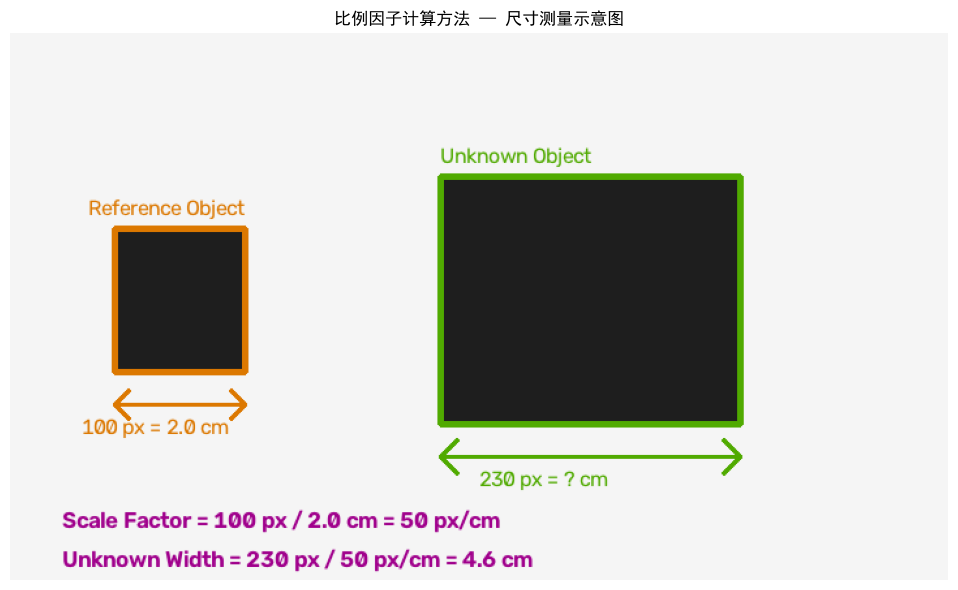

In [11]:
# ── 比例因子法：生成演示场景 ──────────────────────────────────────────────
# 场景描述：
#   左侧：参考物（已知宽度 = 2.0 cm，像素宽度 = 100 px）
#   右侧：待测物（宽度未知，像素宽度约 230 px）

KNOWN_WIDTH_CM = 2.0  # 参考物的实际宽度（厘米）

# 构建演示图像
scene = np.ones((420, 720, 3), dtype=np.uint8) * 245

# 参考物（橙色边框）：像素宽度 = 180-80 = 100 px
cv2.rectangle(scene, (80, 150), (180, 260), (30, 30, 30), -1)
cv2.rectangle(scene, (80, 150), (180, 260), (0, 120, 220), 3)
cv2.putText(scene, 'Reference Object', (60, 140),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 120, 220), 1)
# 宽度标注
cv2.arrowedLine(scene, (80, 285), (180, 285), (0, 120, 220), 2, tipLength=0.15)
cv2.arrowedLine(scene, (180, 285), (80, 285), (0, 120, 220), 2, tipLength=0.15)
cv2.putText(scene, '100 px = 2.0 cm', (55, 308),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 120, 220), 1)

# 待测物（绿色边框）：像素宽度 = 560-330 = 230 px
cv2.rectangle(scene, (330, 110), (560, 300), (30, 30, 30), -1)
cv2.rectangle(scene, (330, 110), (560, 300), (0, 170, 80), 3)
cv2.putText(scene, 'Unknown Object', (330, 100),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 170, 80), 1)
# 宽度标注
cv2.arrowedLine(scene, (330, 325), (560, 325), (0, 170, 80), 2, tipLength=0.08)
cv2.arrowedLine(scene, (560, 325), (330, 325), (0, 170, 80), 2, tipLength=0.08)
cv2.putText(scene, '230 px = ? cm', (360, 348),
            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 170, 80), 1)

# 公式说明
cv2.putText(scene, 'Scale Factor = 100 px / 2.0 cm = 50 px/cm',
            (40, 380), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (140, 0, 160), 2)
cv2.putText(scene, 'Unknown Width = 230 px / 50 px/cm = 4.6 cm',
            (40, 410), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (140, 0, 160), 2)

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
# ax.set_title('比例因子计算方法 — 尺寸测量示意图', fontproperties=_zh_font_xl)
ax.set_title('比例因子计算方法 — 尺寸测量示意图')
ax.axis('off')
plt.tight_layout()
plt.show()

计算得到的比例因子：37.50 px/cm
待测物 1 的实际尺寸：宽 = 1.89 cm，高 = 0.32 cm
待测物 2 的实际尺寸：宽 = 2.80 cm，高 = 3.07 cm
待测物 3 的实际尺寸：宽 = 2.70 cm，高 = 0.97 cm
待测物 4 的实际尺寸：宽 = 6.27 cm，高 = 5.20 cm
待测物 5 的实际尺寸：宽 = 6.19 cm，高 = 0.75 cm
待测物 6 的实际尺寸：宽 = 1.79 cm，高 = 0.32 cm


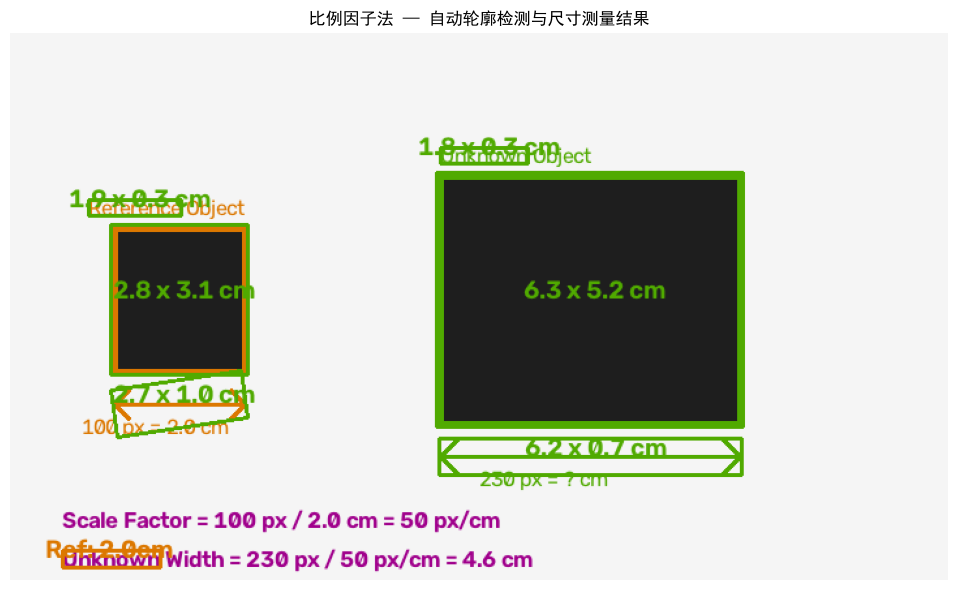

In [12]:
# ── 比例因子法：完整代码实现 ──────────────────────────────────────────────
# 本示例演示如何利用轮廓检测自动计算比例因子并测量物体尺寸

def order_points(pts):
    """将矩形的四个顶点按 [左上, 右上, 右下, 左下] 排序。"""
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # 左上
    rect[2] = pts[np.argmax(s)]   # 右下
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # 右上
    rect[3] = pts[np.argmax(diff)]  # 左下
    return rect

def midpoint(ptA, ptB):
    return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)

# 1. 图像预处理
gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_scene, (7, 7), 0)
edged = cv2.Canny(blurred, 30, 100)
edged = cv2.dilate(edged, None, iterations=1)
edged = cv2.erode(edged, None, iterations=1)

# 2. 轮廓检测
cnts, _ = cv2.findContours(
    edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 过滤面积过小的噪声轮廓，并按 x 坐标从左到右排序
cnts = [c for c in cnts if cv2.contourArea(c) > 500]
cnts = sorted(cnts, key=lambda c: cv2.boundingRect(c)[0])

pixels_per_cm = None
result_img = scene.copy()
measurements = []

for c in cnts:
    # 计算最小外接矩形
    box = cv2.minAreaRect(c)
    box_pts = cv2.boxPoints(box)
    box_pts = np.intp(box_pts)
    ordered = order_points(box_pts.astype('float32'))

    tl, tr, br, bl = ordered
    # 计算矩形的宽和高（像素）
    width_px  = np.linalg.norm(tr - tl)
    height_px = np.linalg.norm(bl - tl)

    # 第一个（最左侧）轮廓作为参考物，初始化比例因子
    if pixels_per_cm is None:
        pixels_per_cm = width_px / KNOWN_WIDTH_CM
        label = f'Ref: {KNOWN_WIDTH_CM:.1f}cm'
        color = (0, 120, 220)
    else:
        w_cm = width_px  / pixels_per_cm
        h_cm = height_px / pixels_per_cm
        label = f'{w_cm:.1f} x {h_cm:.1f} cm'
        color = (0, 170, 80)
        measurements.append((w_cm, h_cm))

    cv2.drawContours(result_img, [box_pts], -1, color, 2)
    cx, cy = int(np.mean(ordered[:, 0])), int(np.mean(ordered[:, 1]))
    cv2.putText(result_img, label, (cx - 50, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

print(f"计算得到的比例因子：{pixels_per_cm:.2f} px/cm")
for i, (w, h) in enumerate(measurements):
    print(f"待测物 {i+1} 的实际尺寸：宽 = {w:.2f} cm，高 = {h:.2f} cm")

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
# ax.set_title('比例因子法 — 自动轮廓检测与尺寸测量结果', fontproperties=_zh_font_xl)
ax.set_title('比例因子法 — 自动轮廓检测与尺寸测量结果')
ax.axis('off')
plt.tight_layout()
plt.show()

---

## 6. 两种方法的对比总结

以下表格从多个维度对张正友标定法和比例因子计算方法进行系统比较：

findfont: Failed to find font weight bold, now using 400.


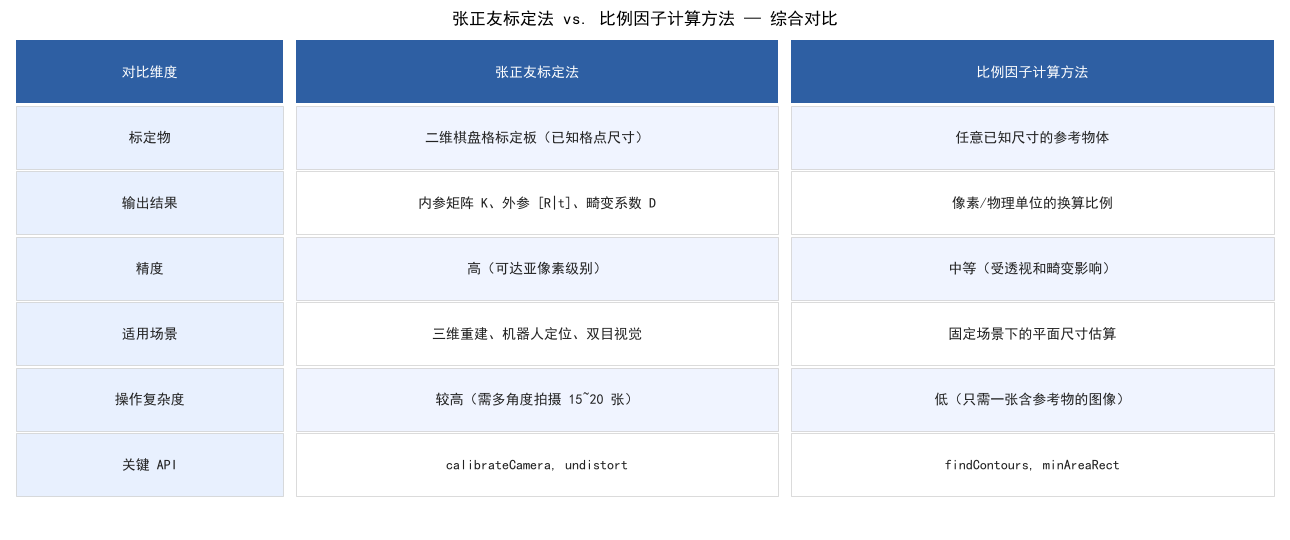

In [13]:
# ── 图：两种方法对比可视化 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axis('off')

headers = ['对比维度', '张正友标定法', '比例因子计算方法']
rows = [
    ['标定物', '二维棋盘格标定板（已知格点尺寸）', '任意已知尺寸的参考物体'],
    ['输出结果', '内参矩阵 K、外参 [R|t]、畸变系数 D', '像素/物理单位的换算比例'],
    ['精度', '高（可达亚像素级别）', '中等（受透视和畸变影响）'],
    ['适用场景', '三维重建、机器人定位、双目视觉', '固定场景下的平面尺寸估算'],
    ['操作复杂度', '较高（需多角度拍摄 15~20 张）', '低（只需一张含参考物的图像）'],
    ['关键 API', 'calibrateCamera, undistort', 'findContours, minAreaRect'],
]

col_widths = [0.22, 0.39, 0.39]
col_starts = [0.0, 0.22, 0.61]
row_height = 0.13
header_y = 0.88

# 绘制表头
for j, (h, x, w) in enumerate(zip(headers, col_starts, col_widths)):
    rect = mpatches.FancyBboxPatch((x + 0.005, header_y), w - 0.01, row_height,
                                    transform=ax.transAxes,
                                    boxstyle='square,pad=0', clip_on=False,
                                    linewidth=0, facecolor='#2e5fa3')
    ax.add_patch(rect)
    # ax.text(x + w/2, header_y + row_height/2, h,
    #         transform=ax.transAxes, ha='center', va='center',
    #         fontproperties=_zh_font_md, color='white', fontweight='bold')
    ax.text(x + w/2, header_y + row_height/2, h,
            transform=ax.transAxes, ha='center', va='center',
            color='white', fontweight='bold')

# 绘制数据行
for i, row in enumerate(rows):
    y = header_y - (i + 1) * (row_height + 0.005)
    bg = '#f0f4ff' if i % 2 == 0 else '#ffffff'
    for j, (cell, x, w) in enumerate(zip(row, col_starts, col_widths)):
        rect = mpatches.FancyBboxPatch((x + 0.005, y), w - 0.01, row_height,
                                        transform=ax.transAxes,
                                        boxstyle='square,pad=0', clip_on=False,
                                        linewidth=0.5, edgecolor='#cccccc',
                                        facecolor=bg if j > 0 else '#e8f0fe')
        ax.add_patch(rect)
        # ax.text(x + w/2, y + row_height/2, cell,
        #         transform=ax.transAxes, ha='center', va='center',
        #         fontproperties=_zh_font_sm, color='#222222')
        ax.text(x + w/2, y + row_height/2, cell,
                transform=ax.transAxes, ha='center', va='center',
                color='#222222')

# ax.set_title('张正友标定法 vs. 比例因子计算方法 — 综合对比',
#              fontproperties=_zh_font_xl, pad=15)
ax.set_title('张正友标定法 vs. 比例因子计算方法 — 综合对比', pad=15)
plt.tight_layout()
plt.show()

### 6.1 方法选择建议

在实际工程中，两种方法的选择取决于具体的应用需求。**张正友标定法**适用于对精度要求高、需要完整三维信息的场景，如机器人手眼标定、双目深度估计、增强现实（AR）等；而**比例因子方法**则适用于场景固定、只需要平面尺寸估算的轻量级应用，如生产线上的零件尺寸检测、文档扫描中的比例估算等。

对于绝大多数需要精确三维感知的计算机视觉系统，推荐优先使用张正友标定法，并结合 OpenCV 的 `calibrateCamera` 接口进行完整的内参、外参和畸变系数的估计。

---

## 7. 参考文献

1. Zhang, Z. (2000). A flexible new technique for camera calibration. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 22(11), 1330–1334.
2. OpenCV Documentation — Camera Calibration and 3D Reconstruction. https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html
3. 尤志远. 相机标定之张正友标定法数学原理详解（含python源码）. 知乎专栏. https://zhuanlan.zhihu.com/p/94244568
4. MathWorks. What Is Camera Calibration? https://www.mathworks.com/help/vision/ug/camera-calibration.html
5. Hartley, R., & Zisserman, A. (2003). *Multiple View Geometry in Computer Vision* (2nd ed.). Cambridge University Press.